In [1]:
import cvxpy as cvx
import numpy as np
import matplotlib.pyplot as plt
# import networkx as nx
import math
from tqdm import tqdm

def cycle_adjacency(n):
    G = np.zeros((n, n), dtype=int)
    for i in range(n):
        G[i, (i + 1) % n] = 1
        G[(i + 1) % n, i] = 1
    return G

def fraction_adjacency(p,q):
    G = np.zeros((p, p), dtype=int)
    for i in range(p):
        for j in range(1,q):
            G[i, (i + j) % p] = 1
            G[(i + j) % p, i] = 1
    return G

def solve_theta(G):
    n = G.shape[0]
    X = cvx.Variable((n, n), symmetric=True)

    constraints = [X >> 0]  # X is positive semidefinite
    constraints.append(cvx.trace(X) == 1)  # Diagonal entries are 1
    for i in range(n):
        for j in range(n):
            if G[i, j] == 1 and i != j:
                constraints.append(X[i, j] == 0)  # Non-edges have zero entries

    objective = cvx.Maximize(cvx.sum(X))
    problem = cvx.Problem(objective, constraints)
    problem.solve()

    return problem.value

#Calculates upper bound at n,d using theta function of cycle graph
def upper_bound(n, d):
    G = cycle_adjacency(n)
    theta_value = solve_theta(G)
    return math.floor(theta_value ** d)

def check_S(n, d):
    k_max = 0
    q_max = []
    for q in range(2, n // 2 + 1):
        q_array = np.array([q**i for i in range(d)])
        # Vectorized: multiply q_array by all t values at once
        t_array = q_array * np.arange(1, n)[:, np.newaxis]
        t_array = np.mod(t_array, n)
        t_array = np.minimum(t_array, n - t_array)
        # Vectorized min of max: find max along each row, then min across rows
        k_plus = t_array.max(axis=1).min()
        if k_plus > k_max:
            k_max = k_plus
            q_max = [q]
        elif k_plus == k_max:
            q_max.append(q)
    return k_max, q_max


from fractions import Fraction
def check_S_fractional(n,d):
    
    k_max = 0
    q_max = []
    
    # # Generate all q values: integers and fractions with denominators 3, 4, 5
    # q_values = set()
    
    # # Add integers
    # for q in range(2, n // 2 + 1):
    #     q_values.add(Fraction(q))
    
    # # Add fractions with denominators 3, 4, 5
    # for denom in [7, 8, 9, 10,11,12,13]:
    #     min_num = 2 * denom
    #     max_num = denom * (n // 2 + 1)
    #     for num in range(min_num, int(max_num) + 1):
    #         q_val = Fraction(num, denom)
    #         q_values.add(q_val)
    
    # # Sort by value
    # q_values = sorted(list(q_values))
    # q_values = []
    q_values = np.linspace(2, int(np.ceil(n))//2, num=500*(int(np.ceil(n))//2-2)+1)

    # for denom in range(3, 6):
    #     for num in range(2*denom, int(denom*(n//2+1))+1):
    #         q_values.append(num/denom)
    # q_values = [39.0000000000001,39,38.9999999999999]
    multi = 1
    for q in q_values:
        q_array = np.array([float(q**i) for i in range(d)])
        # Vectorized: multiply q_array by all t values at once
        t_array = q_array * np.arange(1, n)[:, np.newaxis]
        t_array = np.mod(t_array, n)
        t_array_f = np.minimum(t_array, n - t_array)
        # Vectorized min of max: find max along each row, then min across rows
        k_plus = t_array_f.max(axis=1).min()
        if k_plus > k_max:
            k_max = k_plus
            q_max = [q]
            k_1 = t_array.max(axis=1).min()
            k_2 = (n-t_array).max(axis=1).min()
            if (k_1 == k_2):
                multi = 2
            else:
                multi = 1
        elif k_plus == k_max:
            q_max.append(q)
            k_1 = t_array.max(axis=1).min()
            k_2 = (n-t_array).max(axis=1).min()
            if (k_1 == k_2):
                multi = 2
    return k_max, q_max, multi

from itertools import combinations

def generate_coprime_q_arrays(n, d):
    max_q = n // 2
    results = []

    def backtrack(combo, start):
        if len(combo) == d - 1:
            results.append([1] + list(combo))
            return
        for q in range(start, max_q + 1):
            if all(math.gcd(q, c) == 1 for c in combo):
                combo.append(q)
                backtrack(combo, q + 1)
                combo.pop()

    backtrack([], 2)
    return np.array(results)

def generate_q_arrays(n, d):
    max_q = n // 2
    q_arrays = np.array([np.array([1] + list(combo)) for combo in combinations(range(2, max_q + 1), d - 1)])
    return q_arrays

def check_T(n, d):
    k_max = 0
    q_max = []
    multi = 1
    q_arrays = generate_coprime_q_arrays(n, d)
    #print(f"Number of q arrays to check: {len(q_arrays)}")
    for q_array in q_arrays:
        # Vectorized array creation
        t_array = q_array * np.arange(1, n)[:, np.newaxis]
        t_array = np.mod(t_array, n)
        t_array = np.minimum(t_array, n - t_array)
        # Vectorized min of max
        k_plus = t_array.max(axis=1).min()
        if k_plus > k_max:
            k_max = k_plus
            q_max = q_array
            
    return k_max, q_max

def check_U(n, d):
    k_max = 0
    q_max = []

    # Build all (a, b) with a, b >= 0 and a + b = s for s in 1..n.
    # Each row in coeffs is one coefficient pair [a, b].
    # coeffs = np.array(
    #     [[a, s - a] for s in range(1, n) for a in range(s + 1)],
    #     dtype=np.int64,
    # )
    # Get all pairs (a,b) with a or b 0
    coeffs = np.array(
        [[a, 0] for a in range(1,n)] + [[0, b] for b in range(1,n)],
        dtype=np.int64,
    )
    # coeffs = np.array(
    #     [[a, 0] for a in range(1,n)],
    #     dtype=np.int64,
    # )
    # coeffs = np.delete(coeffs, np.where((coeffs[:, 0] == 0) & (coeffs[:, 1] == 0)), axis = 0)
    for q in combinations(range(2, n // 2 + 1), 2):
        if (math.gcd(q[0],q[1])==1):
            q_array = np.zeros((2, d), dtype=np.int64)
            for j in range(2):
                q_array[j] = np.array([q[j] ** i for i in range(d)], dtype=np.int64)

            # Linear combination for each coefficient pair:
            # t = a*q_array[0] + b*q_array[1]
            t_array = coeffs @ q_array
            t_array = np.mod(t_array, n)
            t_array = np.minimum(t_array, n - t_array)

            # For each (a,b) row, take max over dimensions; then min across rows.
            k_plus = t_array.max(axis=1).min()
            if k_plus > k_max:
                k_max = k_plus
                q_max = [q]
            elif k_plus == k_max:
                q_max.append(q)

    return k_max, q_max

def find_solution(dimensions, SorT, n_set):
    q_max_set = np.zeros((len(dimensions), len(n_set)), dtype=object)
    for d in dimensions:
        print(f"Dimension: {d}")
        for n in tqdm(n_set):
            if (SorT == 'S'):
                max_q, q_max = check_S(n, d)
            elif (SorT == 'U'):
                max_q, q_max = check_U(n, d)
            elif (SorT == 'S_fractional'):
                max_q, q_max, multi = check_S_fractional(n, d)
            else:
                max_q, q_max = check_T(n, d)
            if max_q is not None:
                q_max_set[d-min(dimensions), n-min(n_set)] = max_q
                #print(f"Found solution for n={n}, d={d}: max_q={max_q}, n/q={n/max_q}, q_max={q_max}")
    return q_max_set

  
n_set = range(4,100)
d_min = 2
dimensions = range(d_min, 6)
choice = 'S'  # or 'T' depending on which one you want to check
q_max_set = find_solution(dimensions, choice, n_set)  

n_set = np.array([np.array(n_set) for _ in dimensions])
def filter_q_set(n_set, q_max_set):
    filtered_n_set = []
    filtered_q_max_set = []
    filtered_n_over_q = []
    for d in range(len(n_set)):
        current_n_set = np.asarray(n_set[d], dtype=float)
        current_q_max_set = np.asarray(q_max_set[d], dtype=float)
        current_n_over_q = np.divide(current_n_set, current_q_max_set, out=np.full_like(current_n_set, np.inf), where=current_q_max_set != 0)
        kept_n_set = []
        kept_q_max_set = []
        kept_n_over_q = []
        while len(current_n_set) > 0:
            i = int(np.argmin(current_n_over_q))
            kept_n_set.append(current_n_set[i])
            kept_q_max_set.append(current_q_max_set[i])
            kept_n_over_q.append(current_n_over_q[i])
            # Delete all elements with index i or lower by continuing with the remaining suffix.
            current_n_set = current_n_set[i+1:]
            current_q_max_set = current_q_max_set[i+1:]
            current_n_over_q = current_n_over_q[i+1:]
        filtered_n_set.append(np.array(kept_n_set))
        filtered_q_max_set.append(np.array(kept_q_max_set))
        filtered_n_over_q.append(np.array(kept_n_over_q))
    return np.array(filtered_n_set, dtype=object), np.array(filtered_q_max_set, dtype=object), np.array(filtered_n_over_q, dtype=object)

#n_set, q_max_set, n_over_q = filter_q_set(n_set, q_max_set)
n_over_q = []
for d in range(len(dimensions)):
    current_n_set = np.asarray(n_set[d], dtype=float)
    current_q_max_set = np.asarray(q_max_set[d], dtype=float)
    current_n_over_q = np.divide(
        current_n_set,
        current_q_max_set,
        out=np.full_like(current_n_set, np.inf),
        where=current_q_max_set != 0,
    )
    n_over_q.append(current_n_over_q)

n_over_q = np.array(n_over_q, dtype=object)

def theta(p,q):
    summ = 0
    for i in range(q):
        multi = 1
        for j in range(1,q):
            c_i = math.cos(2*math.pi*i/q)
            a_j = math.cos(2*math.pi/p*math.floor(j*p/q))
            multi = multi*(c_i-a_j)/(1-a_j)
        summ = summ + multi
    return summ*p/q

n = np.linspace(2,20,1810)
theta_n = np.zeros(1810)
for i in tqdm(range(1810)):
    #theta_n[i] = solve_theta(fraction_adjacency(int(n[i]*10),10))
    theta_n[i] = theta(int(n[i]*100),100)
#Plot all n_over_q against n_set values for each dimension different color
plt.figure(figsize=(10, 6))
for d in range(len(dimensions)):
    #plt.step(n_over_q[d],n_set[d]**(1/(d+3)), label=f'Dimension {d+3}', where='post')
        plt.scatter(n_over_q[d],n_set[d]**(1/(d+d_min)), label=f'Dimension {d+d_min}')
plt.plot(n_over_q[0],n_over_q[0], label = "y=x")
plt.plot(n, theta_n, label = "theta")
plt.xlabel('n')
plt.ylabel('n/k')
#Limit x and y axis to minimum of 2
plt.xlim(2,4)
plt.ylim(2,4)
plt.title('n/k vs n for different dimensions')
plt.legend()
plt.show()
    

KeyboardInterrupt: 

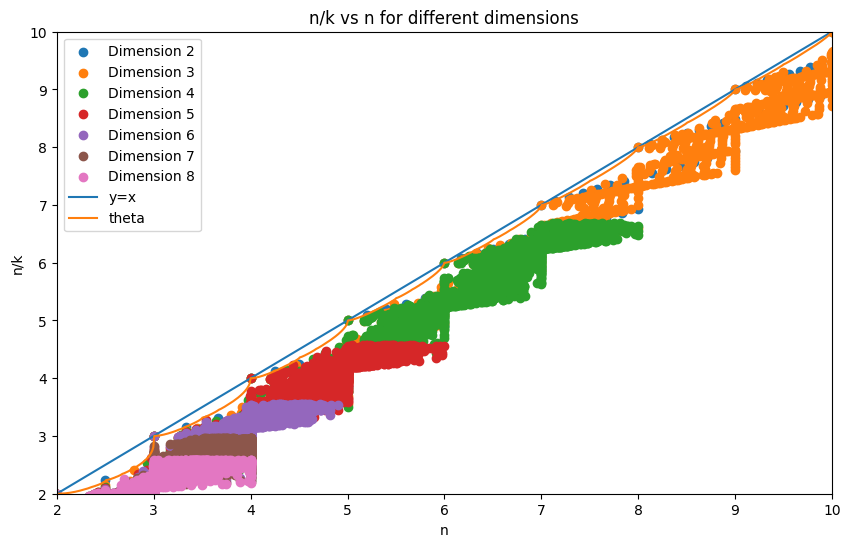

In [26]:
# def theta(p,q):
#     summ = 0
#     for i in range(q):
#         multi = 1
#         for j in range(1,q):
#             c_i = math.cos(2*math.pi*i/q)
#             a_j = math.cos(2*math.pi/p*math.floor(j*p/q))
#             multi = multi*(c_i-a_j)/(1-a_j)
#         summ = summ + multi
#     return summ*p/q

# n = np.linspace(2,20,1810)
# theta_n = np.zeros(1810)
# for i in tqdm(range(1810)):
#     #theta_n[i] = solve_theta(fraction_adjacency(int(n[i]*10),10))
#     theta_n[i] = theta(int(n[i]*100),100)
#Plot all n_over_q against n_set values for each dimension different color
plt.figure(figsize=(10, 6))
for d in range(len(dimensions)):
    #plt.step(n_over_q[d],n_set[d]**(1/(d+3)), label=f'Dimension {d+3}', where='post')
    plt.scatter(n_over_q[d],n_set[d]**(1/(d+d_min)), label=f'Dimension {d+d_min}')
plt.plot(n_over_q[0],n_over_q[0], label = "y=x")
plt.plot(n, theta_n, label = "theta")
plt.xlabel('n')
plt.ylabel('n/k')
#Limit x and y axis to minimum of 2
plt.xlim(2,10)
plt.ylim(2,10)
plt.title('n/k vs n for different dimensions')
plt.legend()
plt.show()


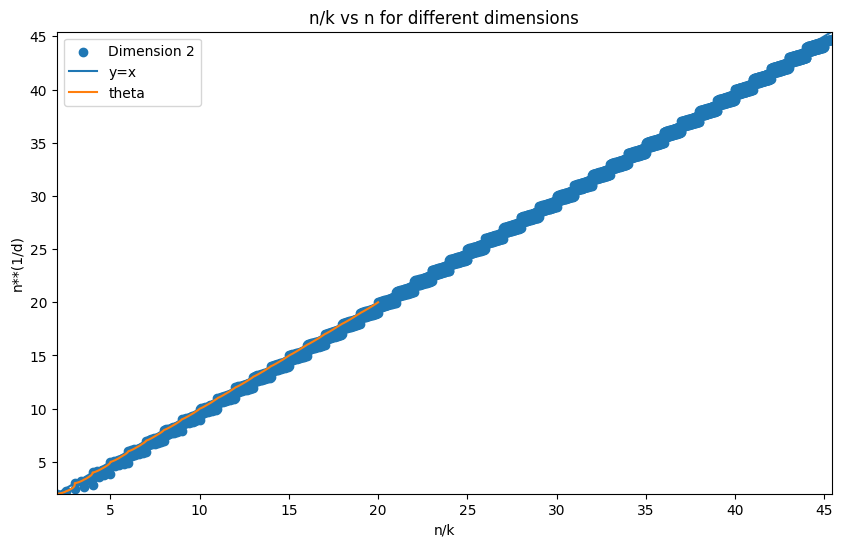

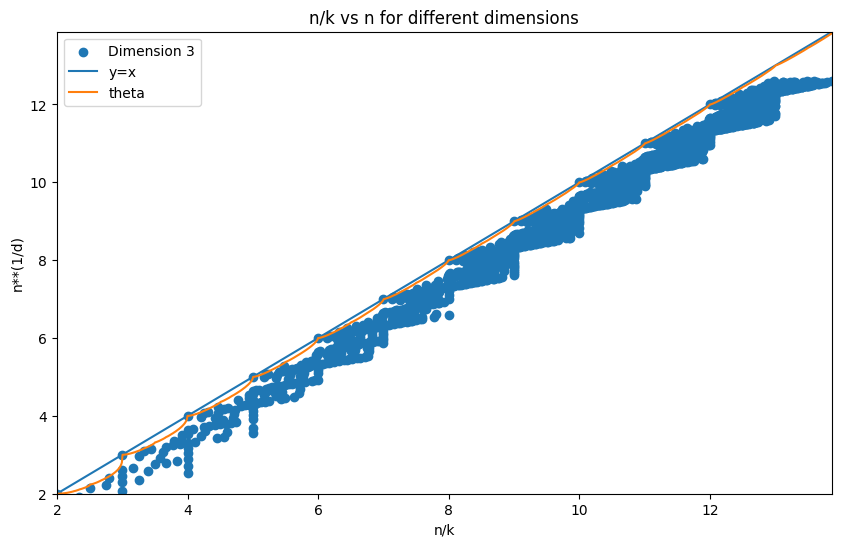

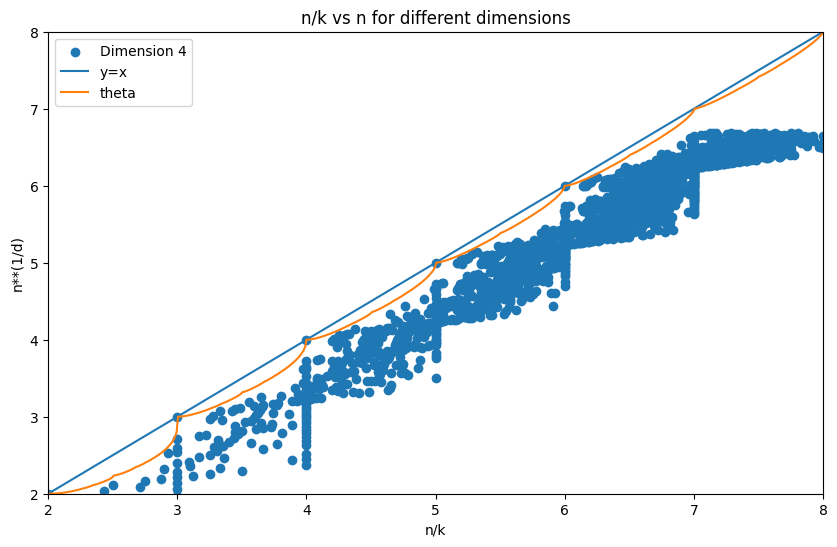

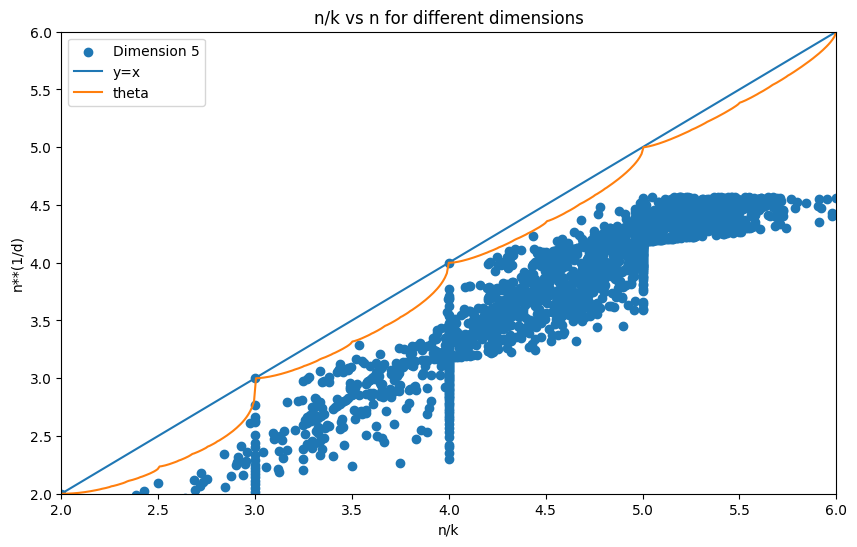

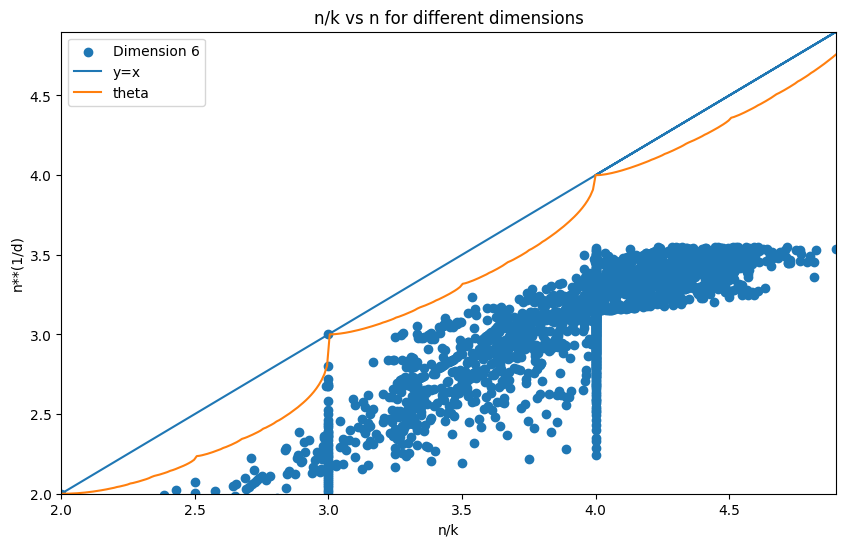

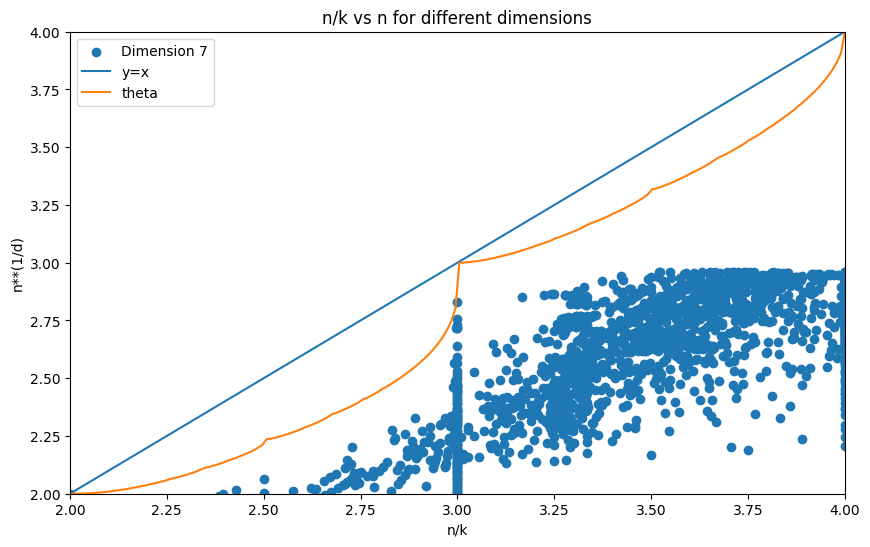

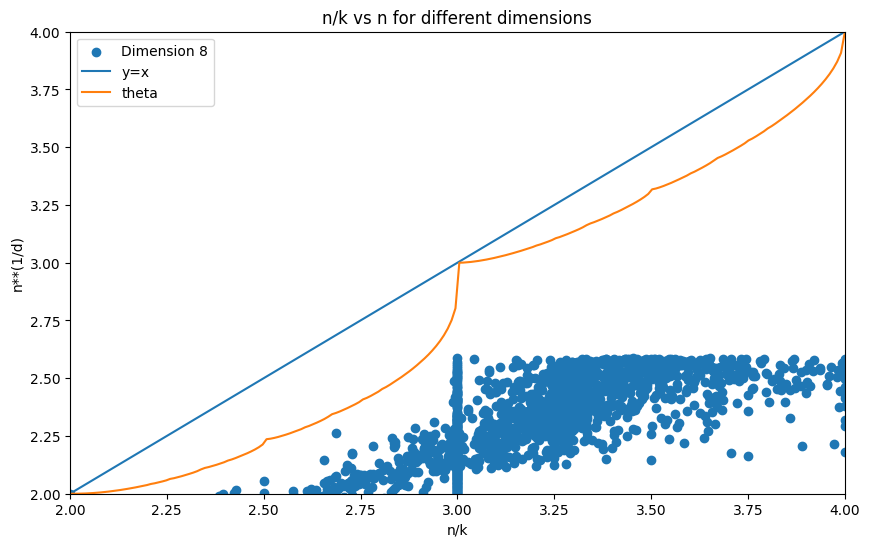

In [27]:
for d in range(len(dimensions)):
    plt.figure(figsize=(10, 6))
    #plt.step(n_over_q[d],n_set[d]**(1/(d+3)), label=f'Dimension {d+3}', where='post')
    plt.scatter(n_over_q[d],n_set[d]**(1/(d+d_min)), label=f'Dimension {d+d_min}')
    plt.plot(n_over_q[0],n_over_q[0], label = "y=x")
    plt.plot(n, theta_n, label = "theta")
    plt.xlabel('n/k')
    plt.ylabel('n**(1/d)')
    #Limit x and y axis but remove inf from set
    plt.xlim(2, max(x for x in n_over_q[d] if math.isfinite(x)))
    plt.ylim(2, max(x for x in n_over_q[d] if math.isfinite(x)))
    plt.title('n/k vs n for different dimensions')
    plt.legend()
    plt.show()

In [ ]:
def filter_q_set2(n_set, q_max_set, d_min):
    n_set_rows = [np.asarray(row, dtype=float) for row in n_set]
    q_max_rows = [np.asarray(row, dtype=float) for row in q_max_set]

    n_over_q_rows = [
        np.divide(n_row, q_row, out=np.full_like(n_row, np.inf), where=q_row != 0)
        for n_row, q_row in zip(n_set_rows, q_max_rows)
    ]
    n_set2_rows = [n_row ** (1 / (d + d_min)) for d, n_row in enumerate(n_set_rows)]

    kept_n_set = []
    kept_q_max_set = []
    kept_n_over_q = []
    kept_n_set2 = []

    active_rows = [np.ones(len(row), dtype=bool) for row in n_set_rows]

    while True:
        best_dim = None
        best_idx = None
        best_value = np.inf

        for d, row_mask in enumerate(active_rows):
            if not len(row_mask):
                continue
            current_values = np.where(row_mask, n_over_q_rows[d], np.inf)
            row_best_idx = int(np.argmin(current_values))
            row_best_value = current_values[row_best_idx]
            if row_best_value < best_value:
                best_value = row_best_value
                best_dim = d
                best_idx = row_best_idx

        if best_dim is None or np.isinf(best_value):
            break

        kept_n_set.append(n_set_rows[best_dim][best_idx])
        kept_q_max_set.append(q_max_rows[best_dim][best_idx])
        kept_n_over_q.append(n_over_q_rows[best_dim][best_idx])
        kept_n_set2.append(n_set2_rows[best_dim][best_idx])

        threshold = n_set2_rows[best_dim][best_idx]
        for d in range(len(active_rows)):
            active_rows[d] &= n_set2_rows[d] > threshold

    return (
        np.asarray(kept_n_set),
        np.asarray(kept_q_max_set),
        np.asarray(kept_n_over_q),
        np.asarray(kept_n_set2),
    )


n_set2, q_max_set2, n_over_q2, n_set2_values = filter_q_set2(n_set, q_max_set, d_min)
plt.figure(figsize=(10, 6))
plt.step(n_over_q2,n_set2_values, label=f'Best values', where='post')
#plt.scatter(n_over_q[d],n_set[d]**(1/(d+4)), label=f'Dimension {d+4}')
plt.plot(n_over_q[0],n_over_q[0], label = "y=x")
plt.plot(n, theta_n, label = "theta")
plt.xlabel('n/k')
plt.ylabel('n**(1/d)')
#Limit x and y axis but remove inf from set
# plt.xlim(2, max(x for x in n_over_q2 if math.isfinite(x)))
# plt.ylim(2, max(x for x in n_over_q2 if math.isfinite(x)))
plt.xlim(4,6)
plt.ylim(4,6)
plt.title('n/k vs n for different dimensions')
plt.legend()
plt.show()    

Start generating solution...
Dimension: 2


100%|██████████| 13/13 [00:00<00:00, 755.13it/s]


Dimension: 3


100%|██████████| 57/57 [00:00<00:00, 602.66it/s]


Dimension: 4


100%|██████████| 241/241 [00:01<00:00, 145.76it/s]


Dimension: 5


100%|██████████| 993/993 [00:41<00:00, 24.11it/s] 


Start filtering solution on d...
Start filtering total solution...


100%|██████████| 201/201 [00:02<00:00, 93.07it/s] 


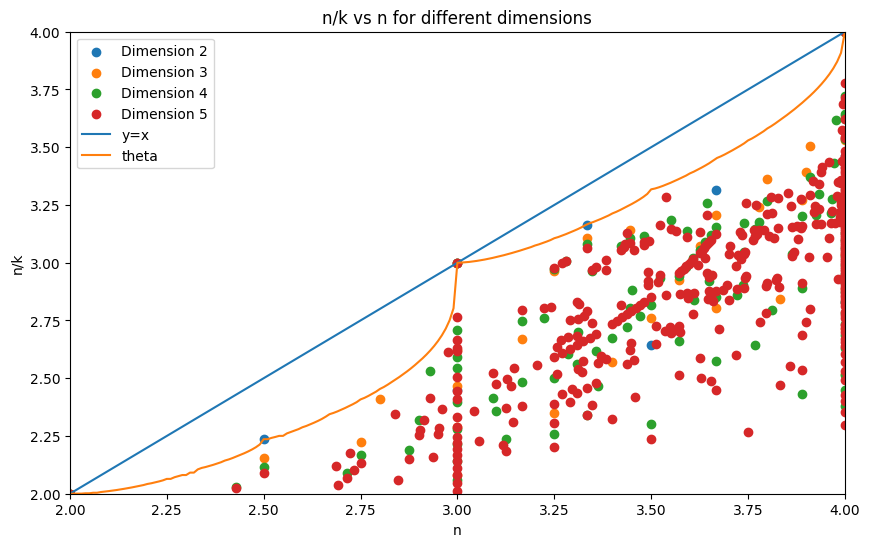

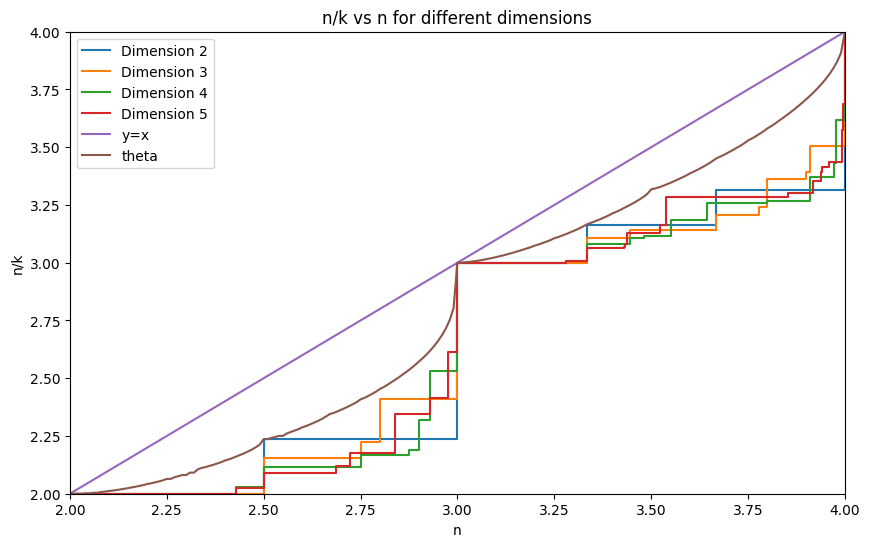

Start generating all solutions...
Dimension: 2


100%|██████████| 13/13 [00:00<00:00, 3655.53it/s]


Dimension: 3


100%|██████████| 57/57 [00:00<00:00, 186.36it/s]


Dimension: 4


...

Dimension: 4


 59%|█████▉    | 143/241 [05:03<03:28,  2.13s/it]


Dimension: 5


 12%|█▏        | 123/993 [05:02<35:42,  2.46s/it]  


Start filtering all total solutions...


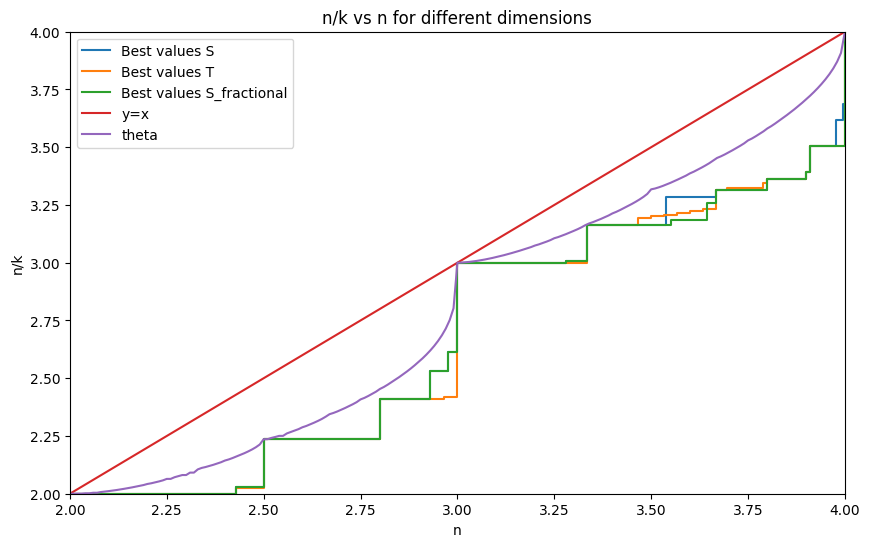

In [21]:
import time
d_min = 2
d_max = 5
min_n = 2
max_n = 4
choice = 'S'
choice2 = 'T'
choice3 = 'S_fractional'
choice4 = 'U'
time_limit = 60*5 #time cap

def generate_solution(d_min, d_max, SorT, min_n, max_n):
    q_max_set = []
    n_set = []
    n_over_q = []
    for d in range(d_min, d_max + 1):
        print(f"Dimension: {d}")
        current_q_max_set = []
        current_n_set = []
        current_n_over_q = []
        deadline = time.monotonic() + time_limit
        for n in tqdm(range(min_n**d, max_n**d + 1)):
            if time.monotonic() >= deadline:
                break
            if (SorT == 'S'):
                max_q, q_max = check_S(n, d)
            elif (SorT == 'U'):
                max_q, q_max = check_U(n, d)
            elif (SorT == 'S_fractional'):
                max_q, q_max, multi = check_S_fractional(n, d)
            else:
                max_q, q_max = check_T(n, d)
            if max_q is not None:
                current_q_max_set.append(max_q)
                current_n_set.append(n)
                current_n_over_q.append(n/max_q)
        q_max_set.append(current_q_max_set)
        n_set.append(current_n_set)
        n_over_q.append(current_n_over_q)
    return n_set, q_max_set, n_over_q

def filter_solution_on_d(n_set, q_max_set, n_over_q):
    filtered_n_set = []
    filtered_q_max_set = []
    filtered_n_over_q = []
    for d in range(len(n_set)):
        current_n_set = np.asarray(n_set[d], dtype=float)
        current_q_max_set = np.asarray(q_max_set[d], dtype=float)
        current_n_over_q = np.asarray(n_over_q[d], dtype=float)
        kept_n_set = []
        kept_q_max_set = []
        kept_n_over_q = []
        while len(current_n_set) > 0:
            i = int(np.argmin(current_n_over_q))
            kept_n_set.append(current_n_set[i])
            kept_q_max_set.append(current_q_max_set[i])
            kept_n_over_q.append(current_n_over_q[i])
            # Delete all elements with index i or lower by continuing with the remaining suffix.
            current_n_set = current_n_set[i+1:]
            current_q_max_set = current_q_max_set[i+1:]
            current_n_over_q = current_n_over_q[i+1:]
        filtered_n_set.append(np.array(kept_n_set))
        filtered_q_max_set.append(np.array(kept_q_max_set))
        filtered_n_over_q.append(np.array(kept_n_over_q))
    return np.array(filtered_n_set, dtype=object), np.array(filtered_q_max_set, dtype=object), np.array(filtered_n_over_q, dtype=object)

print("Start generating solution...")
n_set, q_max_set, n_over_q = generate_solution(d_min, d_max, choice, min_n, max_n)
print("Start filtering solution on d...")
n_filtered, q_filtered, n_over_q_filtered = filter_solution_on_d(n_set, q_max_set, n_over_q)
print("Start filtering total solution...")
n_filtered_total, q_filtered_total, n_over_q_filtered_total, n_rooted_total_filtered = filter_q_set2(n_filtered, q_filtered, d_min)

n = np.linspace(min_n, max_n, 100*(max_n-min_n)+1)
theta_n = np.zeros(100*(max_n-min_n)+1)
for i in tqdm(range(100*(max_n-min_n)+1)):
    theta_n[i] = theta(int(n[i]*100),100)

n_rooted = []
n_rooted_filtered = []
for d in range(len(n_set)):
    current_n_rooted = []
    current_n_rooted_filtered = []
    for i in range(len(n_set[d])):
        current_n_rooted.append(n_set[d][i]**(1/(d+d_min)))
    for i in range(len(n_filtered[d])):
        current_n_rooted_filtered.append(n_filtered[d][i]**(1/(d+d_min)))
    n_rooted_filtered.append(current_n_rooted_filtered)
    n_rooted.append(current_n_rooted)

#Plot all n_over_q against n_set values for each dimension different color
plt.figure(figsize=(10, 6))
for d in range(len(n_set)):
    plt.scatter(n_over_q[d],n_rooted[d], label=f'Dimension {d+d_min}')
plt.plot([min_n,max_n], [min_n, max_n], label = "y=x")
plt.plot(n, theta_n, label = "theta")
plt.xlabel('n')
plt.ylabel('n/k')
#Limit x and y axis to minimum of 2
plt.xlim(min_n,max_n)
plt.ylim(min_n,max_n)
plt.title('n/k vs n for different dimensions')
plt.legend()
plt.show()

#Plot the step plots per dimension
plt.figure(figsize=(10, 6))
for d in range(len(n_set)):
    plt.step(n_over_q_filtered[d],n_rooted_filtered[d], label=f'Dimension {d+d_min}', where='post')
plt.plot([min_n,max_n], [min_n, max_n], label = "y=x")
plt.plot(n, theta_n, label = "theta")
plt.xlabel('n')
plt.ylabel('n/k')
#Limit x and y axis to minimum of 2
plt.xlim(min_n,max_n)
plt.ylim(min_n,max_n)
plt.title('n/k vs n for different dimensions')
plt.legend()
plt.show()

print("Start generating all solutions...")
n_set2, q_max_set2, n_over_q2 = generate_solution(d_min, d_max, choice2, min_n, max_n)
n_set3, q_max_set3, n_over_q3 = generate_solution(d_min, d_max, choice3, min_n, max_n)
#n_set4, q_max_set4, n_over_q4 = generate_solution(d_min, d_max, choice4, min_n, max_n)
print("Start filtering all total solutions...")
n_filtered_total2, q_filtered_total2, n_over_q_filtered_total2, n_rooted_total_filtered2 = filter_q_set2(n_set2, q_max_set2, d_min)
n_filtered_total3, q_filtered_total3, n_over_q_filtered_total3, n_rooted_total_filtered3 = filter_q_set2(n_set3, q_max_set3, d_min)
#n_filtered_total4, q_filtered_total4, n_over_q_filtered_total4, n_rooted_total_filtered4 = filter_q_set2(n_set4, q_max_set4, d_min)

plt.figure(figsize=(10, 6))
plt.step(n_over_q_filtered_total, n_rooted_total_filtered, label=f'Best values {choice}', where='post')
plt.step(n_over_q_filtered_total2, n_rooted_total_filtered2, label=f'Best values {choice2}', where='post')
plt.step(n_over_q_filtered_total3, n_rooted_total_filtered3, label=f'Best values {choice3}', where='post')
#plt.step(n_over_q_filtered_total4, n_rooted_total_filtered4, label=f'Best values {choice4}', where='post')
plt.plot([min_n,max_n], [min_n, max_n], label = "y=x")
plt.plot(n, theta_n, label = "theta")
plt.xlabel('n')
plt.ylabel('n/k')
#Limit x and y axis to minimum of 2
plt.xlim(min_n,max_n)
plt.ylim(min_n,max_n)
plt.title('n/k vs n for different dimensions')
plt.legend()
plt.show()

In [4]:
print(generate_q_arrays(10, 4))

[[1 2 3 4]
 [1 2 3 5]
 [1 2 4 5]
 [1 3 4 5]]
